# Distribución de volumen en altas dimensiones

¿Qué ocurre cuando generamos un punto aleatorio en un espacio de muchas dimensiones? La respuesta puede resultar anti-intuitiva: A medida que aumentamos el número de dimensiones casi todo el volumen está en los extremos, lo que hace que conceptos como la proximidad o la densidad de los datos sean muy diferentes a lo que esperaríamos en dimensiones bajas.

## 1. Instalación de librerías necesarias para el notebook

Si no tenéis instaladas las librerías de la próxima celda, simplemente ejecutadla una vez para que se instalen en vuestro entorno.

In [1]:
!pip -q install numpy pandas matplotlib

In [2]:
!pip install --upgrade pip

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Definición de parámetros de la simulación

En esta sección tienes que definir las siguientes variables:
1. **Rango de valores en las dimensiones del hipercubo**: valor máximo y mínimo que puede tener un punto generado aleatoriamente.
2. **Tamaño del dataset**: número de puntos aleatorios que se van a generar

In [4]:
# Dimensiones del hipercubo
x_max = 1
x_min = -1

# Número de muestras del dataset
samples = 10000

3. **Número de dimensiones**: este parámetro variará a lo largo de la práctica.

In [5]:
n = 5

## 3. Definición de métrica de distancia

Define una función que permita calcular la distancia entre un punto y el origen para un número arbitrario de dimensiones

In [6]:
i = 0
def dist_origen(a):
    """
    Calcula la distancia euclídea entre un punto y el origen. Esto es, el módulo del vector determinado por el punto.
    """
    dist = 0
    cero = np.zeros(len(a))
    for i in range(0, len(a), 1):
        dist += np.sqrt((a[i] - cero[i])**2)

    return dist

In [7]:
# Probamos que funcione correctamente
p1 = np.array([3, 8, -1, 3.5, -2.5])
dist_origen(p1)

np.float64(18.0)

## 4. Conjunto de datos sintético

Genera un `DataFrame` con puntos generados aleatoriamente. Debe tener `m=10000` filas y tantas columnas como coordenadas tenga cada punto.

**Pista**: utiliza la función `np.random.uniform()` para generar números aleatorios siguiendo una distribución uniforme.

In [8]:
def crear_df(samples, n):
    df = pd.DataFrame(np.random.uniform(x_min, x_max, (samples, n)))
    return df

In [9]:
# Comprueba que el dataframe tenga las dimensiones correctas (m x n).
# n=2
df = crear_df(samples, n)

if df.shape == (samples,n):
    print("dimensiones correctas")
else:
    print("dimensiones erradas")

dimensiones correctas


In [10]:
# Observa el contenido del dataframe:
df.head()

,0,1,2,3,4
0,-0.141114,0.400650,-0.399662,0.433296,0.123189
1,0.478188,0.009999,-0.585354,0.927406,0.066069
2,0.854586,-0.985036,-0.630028,0.320280,-0.343237
3,0.844484,-0.062535,-0.445759,0.645146,-0.849467
4,-0.706728,-0.164758,0.143683,-0.327315,0.021550


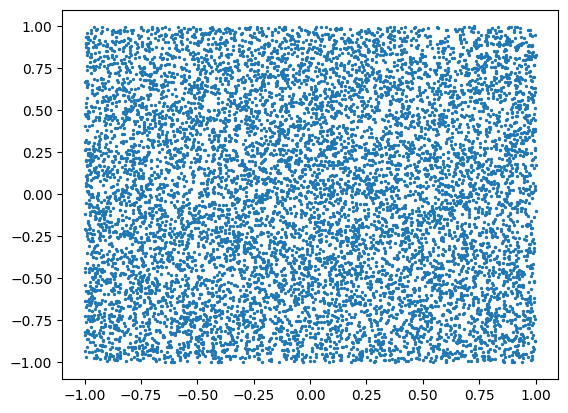

In [11]:
# Representa los puntos en un plano
plt.scatter(df[0], df[1], s = 2)

## 5. Calcula la distancia de cada punto en el dataframe al origen  

**Pista**: Adapta la función para calcular la distancia de un punto al origen para introducirle un dataframe.

In [12]:
def df_dist(df):
    dist = np.zeros(df.shape[0])
    cero = np.zeros(df.shape[1])

    for i in range(0, df.shape[0]):
        for j in range(0,df.shape[1]):
            dist[i] += np.sqrt((df.loc[i,j] - cero[j])**2)
    dist = pd.DataFrame(dist)
    return dist

i = 0
def dist_origen_df(dataframe):
    """
    Calcula la distancia euclídea entre un punto y el origen. Esto es, el módulo del vector determinado por el punto.
    """
    cero = np.zeros(len(dataframe))
    dist = 0
    for i in range(0, len(dataframe), 1):
        dist += np.sqrt((dataframe[i] - cero[i])**2)

    return dist

def df_dist2(df):
    dist = np.zeros(df.shape[0])
    
    for i in range(0, df.shape[0]):
        dist[i] = dist_origen_df(df.loc[i,:])
    dist = pd.DataFrame(dist)
    return dist
    



In [13]:
# Comprueba que funciona correctamente

df_dist(df)

,0
0,1.497910
1,2.067016
2,3.133166
3,2.847391
4,1.364034
...,...
9995,2.542864
9996,1.538571
9997,1.703246
9998,2.695325


In [14]:
df_dist2(df)

,0
0,1.497910
1,2.067016
2,3.133166
3,2.847391
4,1.364034
...,...
9995,2.542864
9996,1.538571
9997,1.703246
9998,2.695325


## 6. Representa la distribución de distancias mediante un histograma

In [15]:
def plot_histogram(df):
    """
    Representa histogramas de las distancias para un valor de n.
    """
    plt.hist(df_dist2(df))
        
    return 

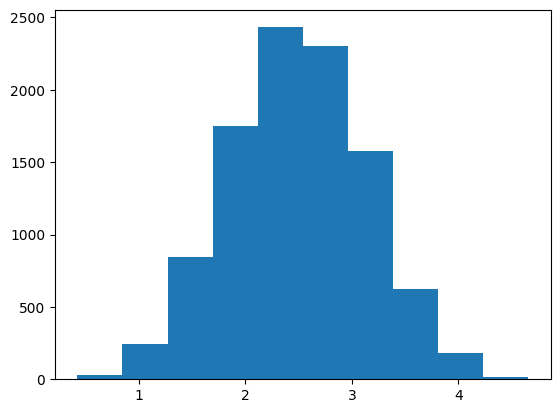

In [16]:
plot_histogram(df)

(array([  36.,  271.,  811., 1632., 2359., 2308., 1595.,  701.,  248.,
          39.]),
 array([0.45478116, 0.86756635, 1.28035154, 1.69313674, 2.10592193,
        2.51870712, 2.93149231, 3.3442775 , 3.75706269, 4.16984788,
        4.58263307]),
 <BarContainer object of 10 artists>)

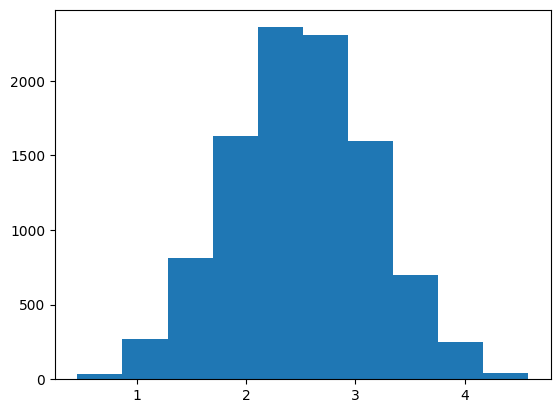

In [17]:
plt.hist(df_dist2(df))

## 7. Repite el proceso para diferentes valores de n

Utiliza los valores de `n=[2, 3, 10, 50, 100, 500]`

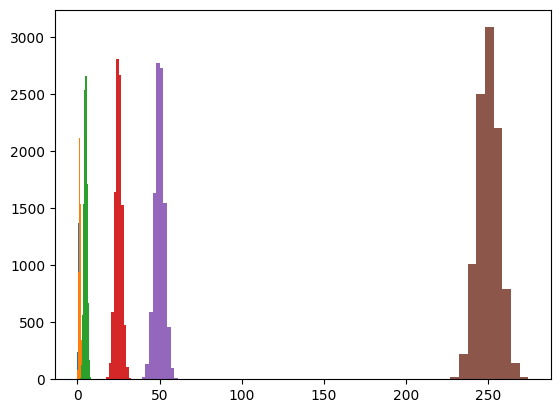

In [17]:
# Dimensiones
n = np.array((2,3,10,50,100,500))

for i in n:
    df = crear_df(samples, i)
    dist = df_dist2(df)
    plot_histogram(dist)
    

In [ ]:
...

## 8. Calcula la distancia media de los puntos al origen para cada valor de n

In [22]:
m_dist = np.zeros(len(n))
for i in range(0,len(n),1):
    val = n[i]
    df = crear_df(samples, val)
    dist = df_dist2(df)
    m = np.mean(dist)
    m_dist[i] = m

m_dist

array([  1.00126814,   1.49669889,   4.99813075,  25.01015129,
        49.98385172, 250.03573601])